In [100]:
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from collections import OrderedDict

In [8]:
BASE_DIR = "../modular_setup_improved/" # for modular_setup_improved_kmn and modular_setup_improved_numpeaks
MASK_PATH = BASE_DIR+"mask_1or2peaks.parquet" # binary classifcation (1 peak or 2 peaks)
DATA_PATH = BASE_DIR+"synthetic+real_dataset_filtered_numpeaks.parquet"
EMBEDDING_PATH = BASE_DIR+"all_fm-rna_embeddings_filtered.pt"
SEED = 42
N_BINS = 50
DEVICE = "cpu"  # change to "cuda" if available

In [9]:
if MASK_PATH is not None:
    data_mask = pd.read_parquet(MASK_PATH)
else:
    data_mask = None

In [ ]:
embeddings_dict = torch.load(EMBEDDING_PATH)

if data_mask is not None:
    embeddings_dict_aftermask = {}
    for key in embeddings_dict.keys():
        if data_mask['num_peaks'][int(key)]:
            embeddings_dict_aftermask[key] = embeddings_dict[key]
    embeddings_dict = embeddings_dict_aftermask

In [85]:
embeddings = embeddings_dict['0'].to(torch.float32)
x = embeddings

# first attempt

In [20]:
x.shape

torch.Size([100, 640])

In [21]:
x.dtype

torch.float32

In [23]:
x.shape[-2]

100

In [31]:
x_row = torch.unsqueeze(x, dim=-3)
x_row.shape

torch.Size([1, 100, 640])

In [32]:
x_col = torch.unsqueeze(x, dim=-2)
x_col.shape

torch.Size([100, 1, 640])

In [34]:
x_row_tiled = torch.tile(x_row, dims=(x.shape[-2],1,1))
x_row_tiled.shape

torch.Size([100, 100, 640])

In [35]:
x_col_tiled = torch.tile(x_col, dims=(1,x.shape[-2],1))
x_col_tiled.shape

torch.Size([100, 100, 640])

In [44]:
outer_concat = torch.cat((x_row_tiled, x_col_tiled), dim=-1)
outer_concat.shape

torch.Size([100, 100, 1280])

In [45]:
outer_concat = torch.unsqueeze(outer_concat, dim=0)
outer_concat = torch.permute(outer_concat, (0,3,1,2))
outer_concat.shape

torch.Size([1, 1280, 100, 100])

In [71]:
conv2d = nn.Conv2d(in_channels=outer_concat.shape[-3], out_channels=32, kernel_size=3, padding='same')

In [72]:
output_conv2d = conv2d(outer_concat)
output_conv2d.shape

torch.Size([1, 32, 100, 100])

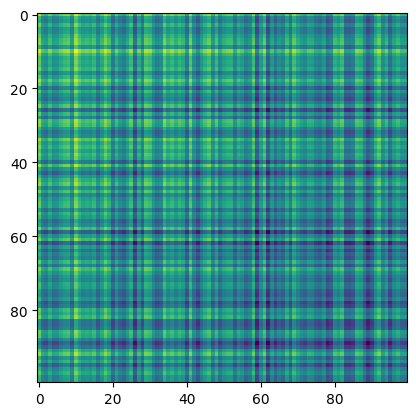

In [73]:
plt.imshow(torch.mean(outer_concat[0,:,:,:], dim=0).detach().numpy())

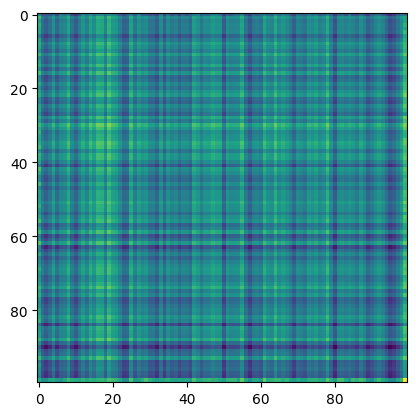

In [74]:
plt.imshow(torch.squeeze(torch.mean(output_conv2d,dim=1)).detach().numpy())

In [70]:
output_conv2d.shape

torch.Size([1, 32, 98, 98])

# copying code from rna-fm github repository

In [86]:
embeddings = embeddings.unsqueeze(0)
embeddings.shape

torch.Size([1, 100, 640])

In [87]:
batch_size, seqlen, hiddendim = embeddings.size()
print(batch_size, seqlen, hiddendim)

1 100 640


In [88]:
embed_in = hiddendim
embed_reduction = 128
embed_reduction_layer = nn.Linear(embed_in, embed_reduction)

In [89]:
embeddings = embed_reduction_layer(embeddings)
embeddings.shape

torch.Size([1, 100, 128])

In [90]:
hiddendim = embed_reduction

In [92]:
embeddings.shape

torch.Size([1, 100, 128])

In [93]:
embeddings = embeddings.unsqueeze(2).expand(batch_size, seqlen, seqlen, hiddendim)
embedding_T = embeddings.permute(0, 2, 1, 3)
pairwise_concat_embedding = torch.cat([embeddings, embedding_T], dim=3)
pairwise_concat_embedding = pairwise_concat_embedding.permute(0, 3, 1, 2)

In [94]:
pairwise_concat_embedding.shape

torch.Size([1, 256, 100, 100])

In [95]:
main_dim = 32

In [96]:
first_layer = nn.Conv2d(embed_reduction*2, main_dim, kernel_size=1)

In [129]:
class MyBasicResBlock(nn.Module):
    expansion: int = 1

    def __init__(
        self,
        inplanes: int,
        planes: int,
        stride: int = 1,
        groups: int = 1,
        dilation: int = 1
    ) -> None:
        super(MyBasicResBlock, self).__init__()

        # Both self.conv1 and self.downsample layers downsample the input when stride != 1
        self.bn1 = nn.BatchNorm2d(inplanes)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=3, stride=stride,
                               padding=dilation, groups=groups, bias=False, dilation=dilation)
        self.dropout = nn.Dropout(p=0.3)
        self.relu2 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=stride,
                               padding=dilation, groups=groups, bias=False, dilation=dilation)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = x

        out = self.bn1(x)
        out = self.relu1(out)
        out = self.conv1(out)
        out = self.dropout(out)
        out = self.relu2(out)
        out = self.conv2(out)
        
        out += identity

        return out

In [105]:
num_res_layers = 32
res_layers = []
for i in range(num_res_layers):
    dilation = pow(2, (i % 3))
    res_layers.append(MyBasicResBlock(inplanes=main_dim, planes=main_dim, dilation=dilation))
res_layers = nn.Sequential(*res_layers)

final_layer = nn.Conv2d(main_dim, main_dim, kernel_size=3, padding=1)

In [106]:
layers = OrderedDict()
layers["first"] = first_layer
layers["resnet"] = res_layers
layers["final"] = final_layer
entire_resnet = nn.Sequential(layers)

In [109]:
features = entire_resnet(pairwise_concat_embedding)

In [111]:
features.shape

torch.Size([1, 32, 100, 100])

In [116]:
mean_pool = features.mean(dim=(-1,-2))
mean_pool.shape

torch.Size([1, 32])

In [118]:
max_pool = features.amax(dim=(-1,-2))
max_pool.shape

torch.Size([1, 32])

In [120]:
pooled = torch.cat([mean_pool, max_pool], dim=1)
pooled.shape

torch.Size([1, 64])

In [121]:
mlp_head_hidden = 64

mlp_head = nn.Sequential(nn.Linear(2*main_dim, mlp_head_hidden),
                         nn.ReLU(),
                         nn.Dropout(p=0.3),
                         nn.Linear(mlp_head_hidden, 1))

In [122]:
logit = mlp_head(pooled)

In [123]:
logit

tensor([[-0.3637]], grad_fn=<AddmmBackward0>)

In [128]:
torch.sigmoid(logit.squeeze())

tensor(0.4101, grad_fn=<SigmoidBackward0>)

In [ ]:
class PairwiseMapCNN(BaseModel):
    """
    RNA-FM embeddings -> pairwise map of embeddings (outer concatenation) -> ResNet32 -> concat mean and max Pool
    -> fully connected layer -> a single output logit to predict whether the folding time distribution has 1 peak or 2 peaks

    Up to ResNet32, the architecture is the same as what the RNA-FM paper (Chen et al 2022) used to predict RNA secondary structure
    Some code was heavily inspired / copied from the corresponding GitHub repo:
    https://github.com/ml4bio/RNA-FM/blob/main/fm/downstream/pairwise_predictor/pairwise_concat.py#L5
    """

    BATCHING = "padded"

    def __init__(self, embedding_dim: int = 640, cnn_channels: int = 128,
                 kernel_sizes: tuple = (3, 4, 5), lstm_hidden: int = 128,
                 lstm_layers: int = 1, num_heads: int = 8,
                 static_feature_size: int = 3, output_size: int = 50,
                 mlp_hidden_size: int = 64, dropout: float = 0.3):
        super().__init__()
        self.convs = nn.ModuleList([
            nn.Conv1d(embedding_dim, cnn_channels, kernel_size=k, padding=k // 2)
            for k in kernel_sizes
        ])
        self.cnn_relu = nn.ReLU()
        cnn_out_dim = cnn_channels * len(kernel_sizes)

        self.lstm = nn.LSTM(
            input_size=cnn_out_dim,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
        )
        lstm_out_dim = lstm_hidden * 2

        self.attention = nn.MultiheadAttention(
            embed_dim=lstm_out_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )

        self.fc = nn.Sequential(
            nn.Linear(lstm_out_dim + static_feature_size, mlp_hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden_size, output_size),
        )

    def forward(self, sequence, structs, static_features, embeddings, lengths=None):
        x = embeddings  # (batch, seq_len, embedding_dim)
        seq_len = x.size(1)

        key_padding_mask = None
        if lengths is not None:
            key_padding_mask = (
                torch.arange(seq_len, device=x.device).unsqueeze(0) >= lengths.unsqueeze(1)
            )

        conv_in = x.transpose(1, 2)  # (batch, embedding_dim, seq_len)
        conv_outs = []
        for conv in self.convs:
            out = self.cnn_relu(conv(conv_in))  # (batch, cnn_channels, seq_len')
            if out.size(-1) > seq_len:
                out = out[:, :, :seq_len]
            elif out.size(-1) < seq_len:
                out = nn.functional.pad(out, (0, seq_len - out.size(-1)))
            conv_outs.append(out)
        cnn_features = torch.cat(conv_outs, dim=1).transpose(1, 2)  # (batch, seq_len, cnn_out_dim)

        use_packing = lengths is not None and not torch.all(lengths == lengths[0])
        if use_packing:
            packed = pack_padded_sequence(
                cnn_features, lengths.cpu(), batch_first=True, enforce_sorted=False
            )
            lstm_out, _ = self.lstm(packed)
            lstm_out, _ = pad_packed_sequence(lstm_out, batch_first=True, total_length=seq_len)
        else:
            lstm_out, _ = self.lstm(cnn_features)

        attn_out, _ = self.attention(
            lstm_out, lstm_out, lstm_out, key_padding_mask=key_padding_mask
        )

        if lengths is not None:
            mask = (~key_padding_mask).unsqueeze(-1).float()
            pooled = (attn_out * mask).sum(dim=1) / lengths.clamp(min=1).unsqueeze(-1).float()
        else:
            pooled = attn_out.mean(dim=1)

        combined = torch.cat([pooled, static_features], dim=-1)
        return self.fc(combined)